# 1. Import Libiraries

In [53]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from pathlib import Path
import joblib

# 2. Load Data

In [45]:
BASE_DIR = Path.cwd()
while not (BASE_DIR / "dataset").exists():
    BASE_DIR = BASE_DIR.parent
data_path = BASE_DIR / "dataset" / "clean_Telco_Customer_Churn.csv"

df = pd.read_csv(data_path)

# 3. Train / Test Split

In [46]:
# =========================
#  Split Data
# =========================
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Data split done successfully")
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Data split done successfully
Train size: (5616, 19)
Test size : (1405, 19)


# 4. Final Pipeline

In [47]:
target_map = {"No": 0, "Yes": 1}
y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

ignored = ['Contract', 'Churn']
onehot_cols = [col for col in df.select_dtypes(include="object").columns if col not in ignored]
ordinal_cols = ['Contract']
contract_order = ["Month-to-month", "One year", "Two year"]
numerical_cols = ["tenure","MonthlyCharges","TotalCharges"]

preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numerical_cols),
        ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), onehot_cols),
        ("ordinal", OrdinalEncoder(categories=[contract_order]), ordinal_cols)
    ],
    remainder="passthrough"
)

# =========================
# 3. Build Final Pipeline
# =========================

xgb_final = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=2.0,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42
    ))
])
print("Final Pipeline is ready")

Final Pipeline is ready


# 5. Train + Final Evaluation

In [48]:
# =========================
# 4. Train Final Model
# =========================
xgb_final.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [49]:
# =========================
# 5. Predictions
# =========================
OPTIMAL_THRESHOLD = 0.45
def predict_churn(pipeline, X_data, threshold=OPTIMAL_THRESHOLD):
    
    probabilities = pipeline.predict_proba(X_data)[:, 1]
    return (probabilities >= threshold).astype(int), probabilities

y_test_preds, y_test_probs = predict_churn(xgb_final, X_test, threshold=OPTIMAL_THRESHOLD)

🎯 FINAL PRODUCTION EVALUATION (Test Set @ Threshold = 0.45)
              precision    recall  f1-score   support

           0     0.9082    0.7331    0.8114      1053
           1     0.4937    0.7784    0.6042       352

    accuracy                         0.7445      1405
   macro avg     0.7010    0.7558    0.7078      1405
weighted avg     0.8044    0.7445    0.7594      1405

🔹 Final Test ROC-AUC Score: 0.8433


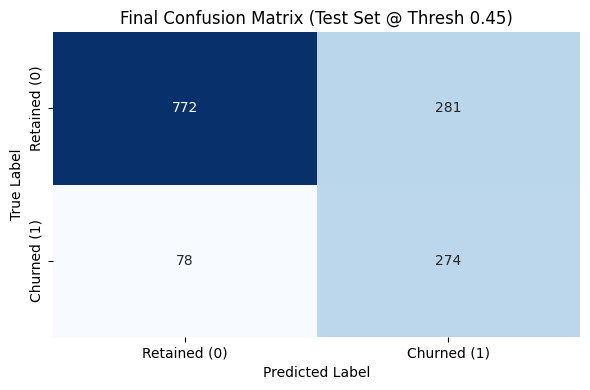

In [50]:
# =========================
# 6. Evaluation
# =========================

print(f"🎯 FINAL PRODUCTION EVALUATION (Test Set @ Threshold = {OPTIMAL_THRESHOLD})")
print("=" * 60)
print(classification_report(y_test, y_test_preds, digits=4))
print(f"🔹 Final Test ROC-AUC Score: {roc_auc_score(y_test, y_test_probs):.4f}")
print("=" * 60)

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Retained (0)", "Churned (1)"],
            yticklabels=["Retained (0)", "Churned (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Final Confusion Matrix (Test Set @ Thresh {OPTIMAL_THRESHOLD})")
plt.tight_layout()
plt.show()

# 6. Final Train

In [51]:
y_encoded = y.map({'No': 0, 'Yes': 1})
xgb_final.fit(X, y_encoded)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


# 7. Save Model

In [52]:
joblib.dump(xgb_final, "..\models\customer_churn_model.pkl")

print("Model saved successfully 💾")

Model saved successfully 💾
